In [1]:
!pip install nilearn scikit-learn pandas matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 33.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay
)

In [4]:
from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

In [5]:
adhd = datasets.fetch_adhd(n_subjects=40)
labels = adhd.phenotypic["adhd"].values[:len(adhd.func)]

atlas = datasets.fetch_atlas_harvard_oxford(
    "cort-maxprob-thr25-2mm"
)

masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    standardize="zscore_sample",
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=2.0
)

corr = ConnectivityMeasure(
    kind="correlation",
    standardize="zscore_sample"
)

X = []
y = []

for func_file, label in zip(adhd.func, labels):
    ts = masker.fit_transform(func_file)
    mat = corr.fit_transform([ts])[0]
    feat = mat[np.triu_indices_from(mat, k=1)]

    X.append(feat)
    y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

[fetch_adhd] Added README.md to /root/nilearn_data

[fetch_adhd] Dataset created in /root/nilearn_data/adhd

[fetch_adhd] Downloading data from https://www.nitrc.org/frs/download.php/7781/adhd40_metadata.tgz ...

[fetch_adhd]  ...done. (1 seconds, 0 min)

[fetch_adhd] Extracting data from /root/nilearn_data/adhd/fbef5baff0b388a8c913a08e1d84e059/adhd40_metadata.tgz...

...

[fetch_atlas_harvard_oxford] Downloaded 12943360 of 25716861 bytes (50.3%%,    2.0s remaining)

[fetch_atlas_harvard_oxford]  ...done. (4 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from 
/root/nilearn_data/fsl/5c734f16e50cc772ef593cab9bb3137b/HarvardOxford.tgz...

[fetch_atlas_harvard_oxford] .. done.

(30, 1128) (30,)


In [6]:
model = Pipeline([
    ("select", SelectKBest(f_classif, k=50)),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [7]:
y_pred = cross_val_predict(model, X, y, cv=cv)
y_prob = cross_val_predict(
    model, X, y, cv=cv, method="predict_proba"
)[:,1]

In [8]:
acc = accuracy_score(y, y_pred)
auc = roc_auc_score(y, y_prob)

print("Accuracy:", round(acc, 2))
print("ROC-AUC :", round(auc, 2))
print()
print(classification_report(y, y_pred))

Accuracy: 0.47
ROC-AUC : 0.33

              precision    recall  f1-score   support

           0       0.53      0.59      0.56        17
           1       0.36      0.31      0.33        13

    accuracy                           0.47        30
   macro avg       0.44      0.45      0.44        30
weighted avg       0.46      0.47      0.46        30



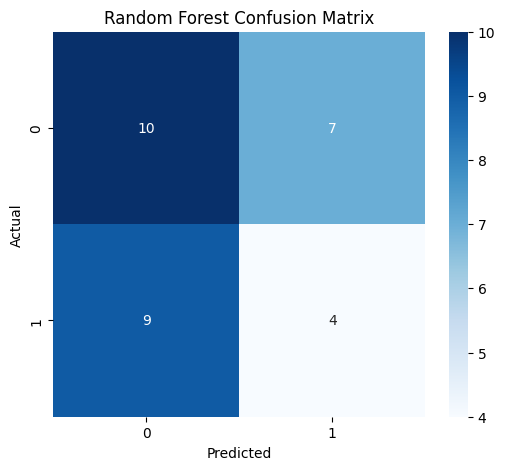

In [9]:
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

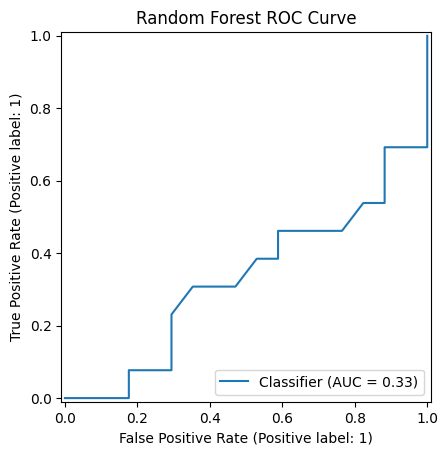

In [10]:
RocCurveDisplay.from_predictions(y, y_prob)
plt.title("Random Forest ROC Curve")
plt.show()

In [11]:
model.fit(X, y)

selector = model.named_steps["select"]
rf = model.named_steps["rf"]

selected_idx = selector.get_support(indices=True)
importances = rf.feature_importances_

feat_df = pd.DataFrame({
    "Feature": selected_idx,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feat_df.head(10)

,Feature,Importance
34,919,0.060768
7,300,0.039278
37,956,0.035563
2,92,0.035454
31,906,0.034629
23,633,0.032331
29,870,0.031735
38,979,0.029535
21,607,0.029267
14,496,0.028925


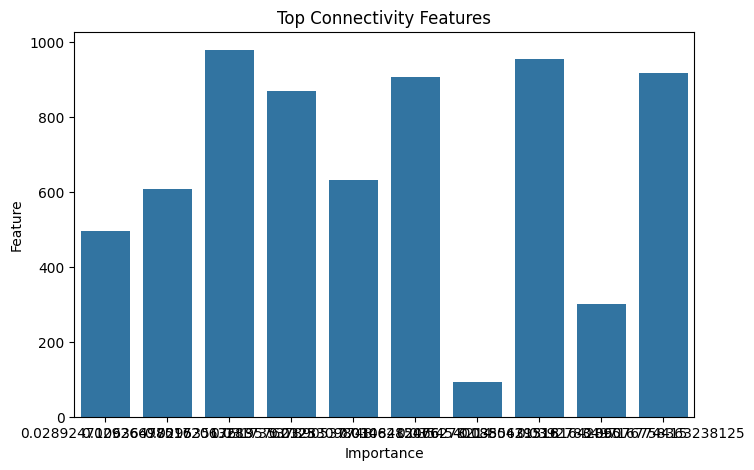

In [12]:
top10 = feat_df.head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top Connectivity Features")
plt.show()